# Compare two coarse-grid calculations with `matplotlib` + `h5py`

This notebook reads painted HDF5 snapshots directly from two BEoRN runs, overlays their global histories, and compares matched snapshots without using BEoRN's built-in plotting helpers.


In [2]:
from pathlib import Path
import re

import h5py
import matplotlib.pyplot as plt
import numpy as np


In [3]:
def read_log_text(path):
    return path.read_bytes().decode("utf-8", errors="ignore")


def parse_snapshot_metadata(log_text):
    z_by_index = {}
    for match in re.finditer(r"z_index=(\d+) \(z=([0-9.]+)\)", log_text):
        z_by_index[int(match.group(1))] = float(match.group(2))

    path_by_index = {}
    pattern = re.compile(r"Data written to (\S*CoevalCube_\S*z_index=(\d+)\S*\.h5)")
    for match in pattern.finditer(log_text):
        path = Path(match.group(1))
        z_index = int(match.group(2))
        path_by_index.setdefault(z_index, path)

    records = []
    for z_index in sorted(set(z_by_index) | set(path_by_index)):
        if z_index in z_by_index and z_index in path_by_index:
            records.append({
                "z_index": z_index,
                "z": z_by_index[z_index],
                "path": path_by_index[z_index],
            })
    return records


def infer_snapshot_dir(records, snapshot_dir_override=None):
    if snapshot_dir_override is not None:
        return Path(snapshot_dir_override)
    for record in records:
        return record["path"].parent
    return None


def build_snapshot_path_lookup(records, snapshot_dir):
    if snapshot_dir is None:
        return {record["z_index"]: record["path"] for record in records}

    resolved = {}
    for record in records:
        filename = record["path"].name
        candidate = snapshot_dir / filename
        resolved[record["z_index"]] = candidate if candidate.exists() else record["path"]
    return resolved


def load_snapshot_fields(snapshot_path):
    with h5py.File(snapshot_path, "r") as handle:
        return {
            "z": float(handle.attrs["z"]),
            "delta_b": handle["delta_b"][...],
            "Grid_Temp": handle["Grid_Temp"][...],
            "Grid_xHII": handle["Grid_xHII"][...],
            "Grid_xal": handle["Grid_xal"][...],
        }


def load_run(run_config):
    log_text = read_log_text(run_config["log_file"])
    records = parse_snapshot_metadata(log_text)
    snapshot_dir = infer_snapshot_dir(records, run_config.get("snapshot_dir_override"))
    snapshot_paths = build_snapshot_path_lookup(records, snapshot_dir)

    summary = []
    for record in records:
        snapshot_path = snapshot_paths[record["z_index"]]
        if not snapshot_path.exists():
            continue

        fields = load_snapshot_fields(snapshot_path)
        summary.append({
            "z_index": record["z_index"],
            "z": fields["z"],
            "path": snapshot_path,
            "mean_xHII": float(np.mean(fields["Grid_xHII"])),
            "mean_Tk": float(np.mean(fields["Grid_Temp"])),
            "mean_xal": float(np.mean(fields["Grid_xal"])),
        })

    if not summary:
        raise FileNotFoundError(
            f"No painted snapshot files were found for {run_config['label']}. "
            "Set snapshot_dir_override if the cache has moved."
        )

    summary.sort(key=lambda item: item["z"])
    return {
        "label": run_config["label"],
        "log_file": run_config["log_file"],
        "snapshot_dir": snapshot_dir,
        "records": records,
        "summary": summary,
        "z": np.array([item["z"] for item in summary]),
        "mean_xHII": np.array([item["mean_xHII"] for item in summary]),
        "mean_Tk": np.array([item["mean_Tk"] for item in summary]),
        "mean_xal": np.array([item["mean_xal"] for item in summary]),
    }


def match_runs_by_redshift(run_a, run_b, atol=5e-3):
    pairs = []
    used_b = set()

    for idx_a, item_a in enumerate(run_a["summary"]):
        best_idx = None
        best_diff = None
        for idx_b, item_b in enumerate(run_b["summary"]):
            if idx_b in used_b:
                continue
            diff = abs(item_a["z"] - item_b["z"])
            if diff <= atol and (best_diff is None or diff < best_diff):
                best_idx = idx_b
                best_diff = diff

        if best_idx is not None:
            used_b.add(best_idx)
            pairs.append((idx_a, best_idx))

    return pairs


def paired_arrays(run_a, run_b, pairs, field):
    a = np.array([run_a[field][idx_a] for idx_a, _ in pairs])
    b = np.array([run_b[field][idx_b] for _, idx_b in pairs])
    z = np.array([run_a["summary"][idx_a]["z"] for idx_a, _ in pairs])
    return z, a, b


def fractional_difference(new, reference, floor=1e-12):
    denom = np.maximum(np.abs(reference), floor)
    return (new - reference) / denom


In [22]:
RUNS = [
    {
        "label": "merged",
        "log_file": Path("/xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test/output/logs_a36e8307.log"),
        "snapshot_dir_override": None,
    },
    {
        "label": "v2-stochastic",
        "log_file": Path("/xdisk/timeifler/yhhuang/BEoRN-v2/thesan_run_fstar/output/logs_295e84bbb8a4b6ca6bed5be6a37c07fc.log"),
        "snapshot_dir_override": None,
    },
]


In [24]:
loaded_runs = [load_run(run_config) for run_config in RUNS]

for run in loaded_runs:
    print(run["label"])
    print(f"  log: {run['log_file']}")
    print(f"  snapshot dir: {run['snapshot_dir']}")
    print(f"  loaded snapshots: {len(run['summary'])}")
    print(f"  z range: {run['z'].min():.2f} -> {run['z'].max():.2f}")


merged
  log: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test/output/logs_a36e8307.log
  snapshot dir: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test/cache/painted_output_fstar_dist_lognormal_sigma_0.1_seed_12345
  loaded snapshots: 26
  z range: 6.66 -> 19.22
v2-stochastic
  log: /xdisk/timeifler/yhhuang/BEoRN-v2/thesan_run_fstar/output/logs_295e84bbb8a4b6ca6bed5be6a37c07fc.log
  snapshot dir: /xdisk/timeifler/yhhuang/BEoRN-v2/thesan_run_fstar/cache/painted_output_fstar_dist_lognormal_sigma_0.1_seed_12345
  loaded snapshots: 25
  z range: 6.66 -> 18.46


In [25]:
run_new = loaded_runs[0]
run_old = loaded_runs[1]
pairs = match_runs_by_redshift(run_new, run_old, atol=5e-3)

print(f"Matched {len(pairs)} snapshots by redshift.")
if pairs:
    z_common = np.array([run_new['summary'][idx_a]['z'] for idx_a, _ in pairs])
    print(f"Common z range: {z_common.min():.2f} -> {z_common.max():.2f}")
else:
    print("No common snapshots found. Increase the matching tolerance if needed.")


Matched 13 snapshots by redshift.
Common z range: 6.66 -> 17.17


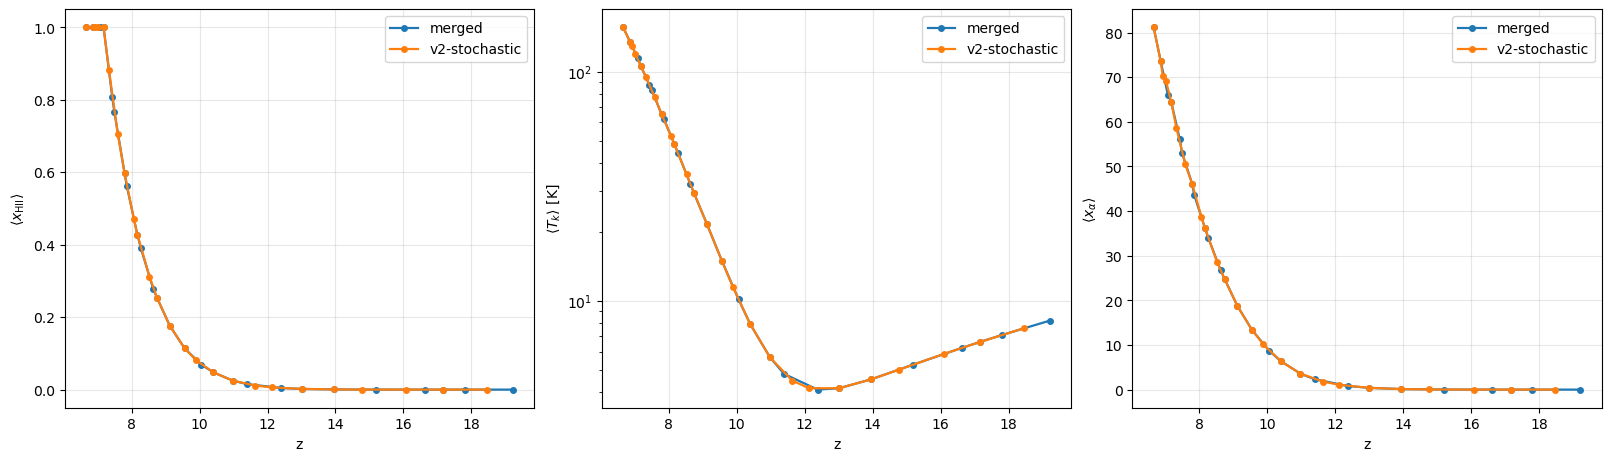

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True, sharex=True)

plot_specs = [
    ("mean_xHII", r"$\langle x_{\mathrm{HII}} \rangle$", "linear"),
    ("mean_Tk", r"$\langle T_k \rangle$ [K]", "log"),
    ("mean_xal", r"$\langle x_\alpha \rangle$", "linear"),
]

colors = ["tab:blue", "tab:orange"]
for run, color in zip(loaded_runs, colors):
    for ax, (field, ylabel, scale) in zip(axes, plot_specs):
        ax.plot(run["z"], run[field], marker="o", lw=1.6, ms=4, label=run["label"], color=color)
        if scale == "log":
            ax.set_yscale("log")
        ax.set_xlabel("z")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()


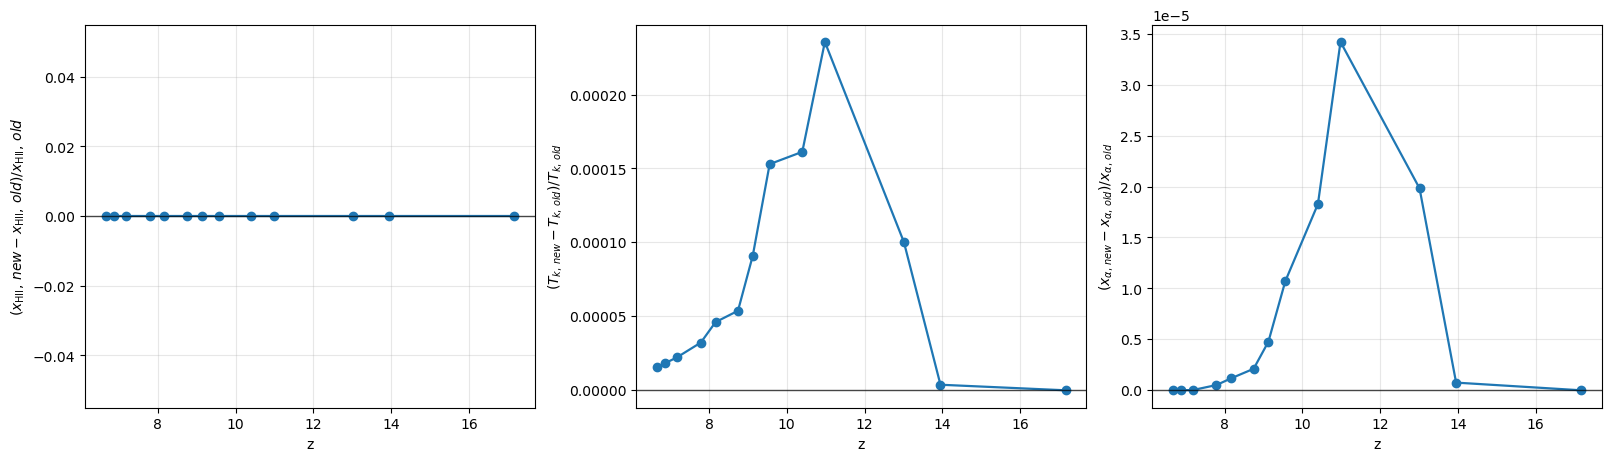

In [27]:
if not pairs:
    raise ValueError("No matched snapshots are available for a difference plot.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True, sharex=True)
diff_specs = [
    ("mean_xHII", r"$(x_{\mathrm{HII}},\,new - x_{\mathrm{HII}},\,old) / x_{\mathrm{HII}},\,old$"),
    ("mean_Tk", r"$(T_{k,\,new} - T_{k,\,old}) / T_{k,\,old}$"),
    ("mean_xal", r"$(x_{\alpha,\,new} - x_{\alpha,\,old}) / x_{\alpha,\,old}$"),
]

for ax, (field, ylabel) in zip(axes, diff_specs):
    z_common, new_values, old_values = paired_arrays(run_new, run_old, pairs, field)
    ax.plot(z_common, fractional_difference(new_values, old_values), marker="o", lw=1.6)
    ax.axhline(0.0, color="black", lw=1.0, alpha=0.7)
    ax.set_xlabel("z")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plt.show()


In [28]:
comparison_rows = []
for idx_a, idx_b in pairs:
    item_a = run_new["summary"][idx_a]
    item_b = run_old["summary"][idx_b]
    comparison_rows.append({
        "z_new": item_a["z"],
        "z_old": item_b["z"],
        "dxHII_frac": fractional_difference(np.array([item_a["mean_xHII"]]), np.array([item_b["mean_xHII"]]))[0],
        "dTk_frac": fractional_difference(np.array([item_a["mean_Tk"]]), np.array([item_b["mean_Tk"]]))[0],
        "dxal_frac": fractional_difference(np.array([item_a["mean_xal"]]), np.array([item_b["mean_xal"]]))[0],
    })

comparison_rows[:10]


[{'z_new': 6.661735534667969,
  'z_old': 6.661735534667969,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(1.5509383514127987e-05),
  'dxal_frac': np.float64(0.0)},
 {'z_new': 6.869392395019531,
  'z_old': 6.869392395019531,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(1.81664281605645e-05),
  'dxal_frac': np.float64(1.9318004737096726e-16)},
 {'z_new': 7.175846099853516,
  'z_old': 7.175846099853516,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(2.2130537723810255e-05),
  'dxal_frac': np.float64(0.0)},
 {'z_new': 7.791370391845703,
  'z_old': 7.791370391845703,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(3.2178912340555164e-05),
  'dxal_frac': np.float64(5.005794229298113e-07)},
 {'z_new': 8.168688774108887,
  'z_old': 8.168688774108887,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(4.599203275208262e-05),
  'dxal_frac': np.float64(1.1627442375644303e-06)},
 {'z_new': 8.746610641479492,
  'z_old': 8.746610641479492,
  'dxHI

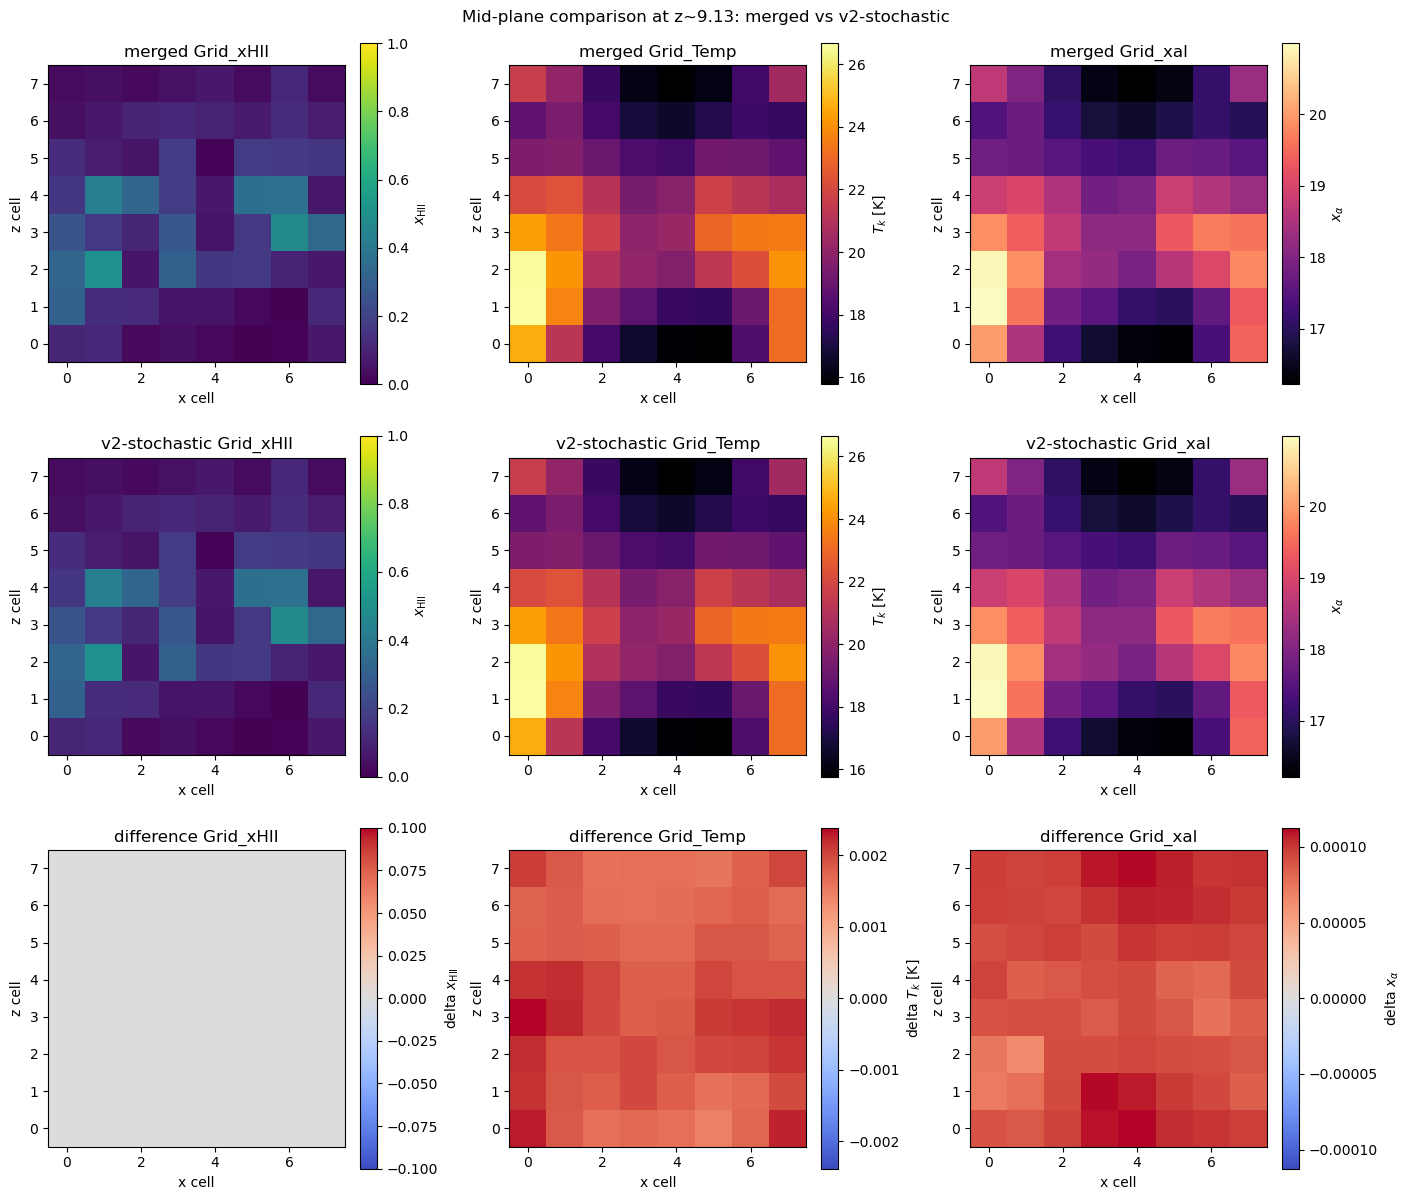

In [29]:
target_pair = pairs[len(pairs) // 2]
new_item = run_new["summary"][target_pair[0]]
old_item = run_old["summary"][target_pair[1]]

fields_new = load_snapshot_fields(new_item["path"])
fields_old = load_snapshot_fields(old_item["path"])
slice_index = fields_new["Grid_xHII"].shape[1] // 2

fig, axes = plt.subplots(3, 3, figsize=(14, 12), constrained_layout=True)
fig.suptitle(
    f"Mid-plane comparison at z~{new_item['z']:.2f}: {run_new['label']} vs {run_old['label']}"
)

plot_specs = [
    ("Grid_xHII", "viridis", {"vmin": 0.0, "vmax": 1.0}, r"$x_{\mathrm{HII}}$"),
    ("Grid_Temp", "inferno", {}, r"$T_k$ [K]"),
    ("Grid_xal", "magma", {}, r"$x_\alpha$"),
]

for col, (field_name, cmap, kwargs, cbar_label) in enumerate(plot_specs):
    new_slice = fields_new[field_name][:, slice_index, :]
    old_slice = fields_old[field_name][:, slice_index, :]
    diff_slice = new_slice - old_slice

    im0 = axes[0, col].imshow(new_slice, origin="lower", cmap=cmap, **kwargs)
    axes[0, col].set_title(f"{run_new['label']} {field_name}")
    fig.colorbar(im0, ax=axes[0, col], label=cbar_label)

    im1 = axes[1, col].imshow(old_slice, origin="lower", cmap=cmap, **kwargs)
    axes[1, col].set_title(f"{run_old['label']} {field_name}")
    fig.colorbar(im1, ax=axes[1, col], label=cbar_label)

    vmax = np.max(np.abs(diff_slice))
    im2 = axes[2, col].imshow(diff_slice, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[2, col].set_title(f"difference {field_name}")
    fig.colorbar(im2, ax=axes[2, col], label=f"delta {cbar_label}")

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel("x cell")
        ax.set_ylabel("z cell")

plt.show()


coarse_grid_test (pre-merge)
  log: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test/output/logs_a36e8307.log
  snapshot dir: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test/cache/painted_output_fstar_dist_lognormal_sigma_0.1_seed_12345
  loaded snapshots: 26
  z range: 6.662 -> 19.219
coarse_grid_test_merged
  log: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test_merged/output/logs_eff80033.log
  snapshot dir: /xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test_merged/cache/painted_output_fstar_dist_lognormal_sigma_0.1_seed_12345
  loaded snapshots: 48
  z range: 6.517 -> 13.011
Matched 20 snapshots by redshift.


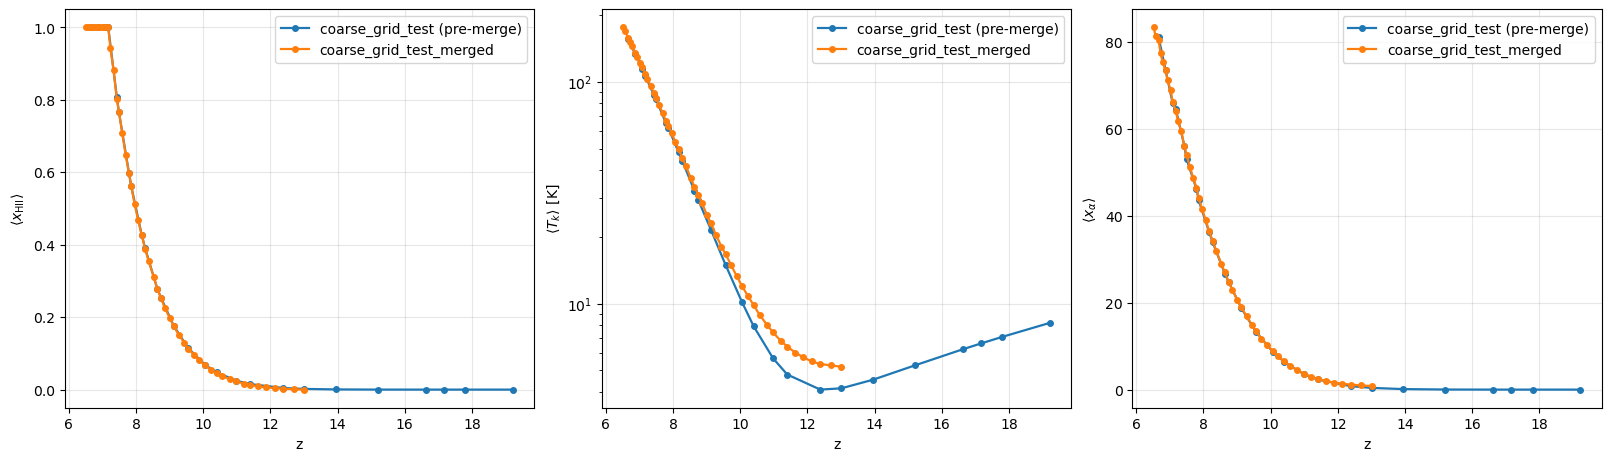

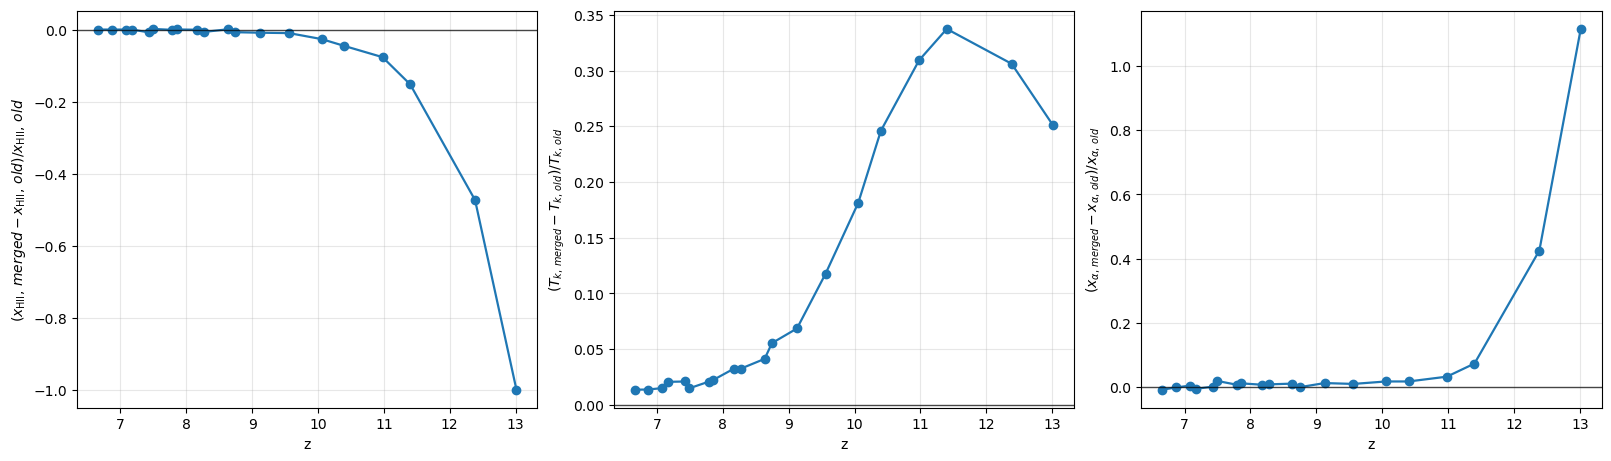

[{'z_old': 6.661735534667969,
  'z_merged': 6.661735534667969,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(0.01366271484539476),
  'dxal_frac': np.float64(-0.008679169404774468)},
 {'z_old': 6.869392395019531,
  'z_merged': 6.869392395019531,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(0.013804654879469757),
  'dxal_frac': np.float64(-0.0017994842722431094)},
 {'z_old': 7.082677841186523,
  'z_merged': 7.082677841186523,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(0.015100754151185048),
  'dxal_frac': np.float64(0.004031928900819993)},
 {'z_old': 7.175846099853516,
  'z_merged': 7.175846099853516,
  'dxHII_frac': np.float64(0.0),
  'dTk_frac': np.float64(0.02070817178961824),
  'dxal_frac': np.float64(-0.00584136506579454)},
 {'z_old': 7.429579734802246,
  'z_merged': 7.429579734802246,
  'dxHII_frac': np.float64(-0.007590476369588323),
  'dTk_frac': np.float64(0.02100829191218246),
  'dxal_frac': np.float64(0.000770451214121193)},
 {'z_old': 7

In [4]:
COMPARE_ROOTS = [
    {
        "label": "coarse_grid_test (pre-merge)",
        "root": Path("/xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test"),
    },
    {
        "label": "coarse_grid_test_merged",
        "root": Path("/xdisk/timeifler/yhhuang/BEoRN-v2/coarse_grid_test_merged"),
    },
]


def latest_log_file(run_root):
    candidates = sorted((run_root / "output").glob("logs_*.log"), key=lambda path: path.stat().st_mtime)
    if not candidates:
        raise FileNotFoundError(f"No logs_*.log files found under {run_root / 'output'}")
    return candidates[-1]


compare_runs = [
    {
        "label": item["label"],
        "log_file": latest_log_file(item["root"]),
        "snapshot_dir_override": None,
    }
    for item in COMPARE_ROOTS
]

compare_loaded = [load_run(run_config) for run_config in compare_runs]

for run in compare_loaded:
    print(run["label"])
    print(f"  log: {run['log_file']}")
    print(f"  snapshot dir: {run['snapshot_dir']}")
    print(f"  loaded snapshots: {len(run['summary'])}")
    print(f"  z range: {run['z'].min():.3f} -> {run['z'].max():.3f}")

compare_old = compare_loaded[0]
compare_new = compare_loaded[1]
compare_pairs = match_runs_by_redshift(compare_old, compare_new, atol=5e-3)

print(f"Matched {len(compare_pairs)} snapshots by redshift.")
if not compare_pairs:
    raise ValueError("No matched snapshots were found between the two coarse-grid directories.")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True, sharex=True)
history_specs = [
    ("mean_xHII", r"$\langle x_{\mathrm{HII}} \rangle$", "linear"),
    ("mean_Tk", r"$\langle T_k \rangle$ [K]", "log"),
    ("mean_xal", r"$\langle x_\alpha \rangle$", "linear"),
]

colors = ["tab:blue", "tab:orange"]
for run, color in zip(compare_loaded, colors):
    for ax, (field, ylabel, scale) in zip(axes, history_specs):
        ax.plot(run["z"], run[field], marker="o", lw=1.6, ms=4, label=run["label"], color=color)
        if scale == "log":
            ax.set_yscale("log")
        ax.set_xlabel("z")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)

for ax in axes:
    ax.legend()

plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True, sharex=True)
diff_specs = [
    ("mean_xHII", r"$(x_{\mathrm{HII}},\,merged - x_{\mathrm{HII}},\,old) / x_{\mathrm{HII}},\,old$"),
    ("mean_Tk", r"$(T_{k,\,merged} - T_{k,\,old}) / T_{k,\,old}$"),
    ("mean_xal", r"$(x_{\alpha,\,merged} - x_{\alpha,\,old}) / x_{\alpha,\,old}$"),
]

for ax, (field, ylabel) in zip(axes, diff_specs):
    z_common, old_values, new_values = paired_arrays(compare_old, compare_new, compare_pairs, field)
    ax.plot(z_common, fractional_difference(new_values, old_values), marker="o", lw=1.6)
    ax.axhline(0.0, color="black", lw=1.0, alpha=0.7)
    ax.set_xlabel("z")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)

plt.show()

comparison_rows = []
for idx_old, idx_new in compare_pairs:
    item_old = compare_old["summary"][idx_old]
    item_new = compare_new["summary"][idx_new]
    comparison_rows.append({
        "z_old": item_old["z"],
        "z_merged": item_new["z"],
        "dxHII_frac": fractional_difference(np.array([item_new["mean_xHII"]]), np.array([item_old["mean_xHII"]]))[0],
        "dTk_frac": fractional_difference(np.array([item_new["mean_Tk"]]), np.array([item_old["mean_Tk"]]))[0],
        "dxal_frac": fractional_difference(np.array([item_new["mean_xal"]]), np.array([item_old["mean_xal"]]))[0],
    })

comparison_rows[:10]
